#### Import Libraries and General Settings

In [25]:
import sys
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    KFold,
    RepeatedKFold,
    train_test_split,
    learning_curve,
    cross_validate,
)
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import optuna.logging

optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.ERROR)
import logging

logging.getLogger("lightgbm").setLevel(logging.ERROR)
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)


import catboost, xgboost, lightgbm, sklearn, matplotlib

print("Python:", sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("Optuna:", optuna.__version__)
print("CatBoost:", catboost.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)
print("Sklearn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)

Python: 3.11.14 (main, Oct 10 2025, 08:54:03) [GCC 11.4.0]
numpy: 2.4.1
pandas: 3.0.0
Optuna: 4.7.0
CatBoost: 1.2.8
XGBoost: 3.1.3
LightGBM: 4.6.0
Sklearn: 1.4.2
matplotlib: 3.10.8
seaborn: 0.13.2


#### Load dataset

In [26]:
melbourne_file_path = 'dataset/melb_data.csv'
melbourne_data = pd.read_csv(melbourne_file_path) 

#### Dataset

In [3]:
melbourne_data

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


#### Statistical summary of the columns

In [4]:
melbourne_data.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


#### Number of rows, columns, data types, number of non-null values

In [5]:
melbourne_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

#### Copy the dataset

In [6]:
melbourne_data_copy = melbourne_data.copy(deep=True)

#### Copy the Suburb column

In [7]:
suburb_copy = melbourne_data['Suburb'].copy(deep=True)

#### Data processing

In [8]:
# Convert strings to integers
for c in melbourne_data.columns:
    if melbourne_data[c].dtype == "str":
        lbl = LabelEncoder()
        lbl.fit(list(melbourne_data[c].values))
        melbourne_data[c] = lbl.transform(list(melbourne_data[c].values))

LabelEncoder was used to transform strings into integers and encode categorical variables. Among several strategies tested, this encoding provided the best performance in cross-validation with the models, without introducing bias into the predictions and maintaining the interpretability of the model.

#### Complete missing data

In [9]:
melbourne_data.fillna({"Car": 0}, inplace=True)
melbourne_data["YearBuilt"] = melbourne_data.groupby("Postcode")["YearBuilt"].transform(
    lambda x: x.fillna(x.mean())
)
melbourne_data["BuildingArea"] = melbourne_data.groupby("Postcode")[
    "BuildingArea"
].transform(lambda x: x.fillna(x.mean()))
melbourne_data["CouncilArea"] = melbourne_data.groupby("Postcode")[
    "CouncilArea"
].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)

#### Delete rows where the missing YearBuilt and BuildingArea values ​​do not match any other Postcode

In [10]:
melbourne_data = melbourne_data.dropna(subset=["YearBuilt"])
melbourne_data = melbourne_data.dropna(subset=["BuildingArea"])

#### Create new features to improve the accuracy rate

In [11]:
melbourne_data["Rooms_type"] = (
    melbourne_data["Rooms"] * melbourne_data["Type"]
)
melbourne_data["Bedroom2_type"] = (
    melbourne_data["Bedroom2"] * melbourne_data["Type"]
) 

#### Separate the dataset into features and price

In [12]:
X = melbourne_data.drop(['Price'], axis=1)
y = melbourne_data['Price']

#### Split train/test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)


*Train–Test Split Strategy*

**A 90%–10% train–test split was used to maximize training data, with cross-validation employed to ensure robust and stable evaluation despite the smaller test set.**
 Hyperparameter selection and intermediate model evaluation were performed using cross-validation, which compensates for the smaller proportion of the test set and ensures robust and stable performance metrics.


#### CV evaluation function

In [14]:
def evaluate_model_cv(model, X, y, cv_splits=5):
    cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
    scoring = {"rmse": "neg_root_mean_squared_error", "r2": "r2"}

    cv_results = cross_validate(
        model, X, y, cv=cv, scoring=scoring, return_train_score=True, n_jobs=1
    )

    train_rmse = -cv_results["train_rmse"]
    test_rmse = -cv_results["test_rmse"]
    train_r2 = cv_results["train_r2"]
    test_r2 = cv_results["test_r2"]

    return {
        "Train RMSE": np.mean(train_rmse),
        "Test RMSE": np.mean(test_rmse),
        "Test RMSE std": np.std(test_rmse),
        "Gap RMSE": np.mean(test_rmse) - np.mean(train_rmse),
        "Gap RMSE %": (np.mean(test_rmse) - np.mean(train_rmse))
        / np.mean(test_rmse)
        * 100,
        "Train R2": np.mean(train_r2),
        "Test R2": np.mean(test_r2),
        "Gap R2": (np.mean(train_r2) - np.mean(test_r2)),
    }

#### Define ranges for each parameter of each model
*Optuna was used to optimize each model*

*Selected models:*
- **CatBoostRegressor**
- **XGBRegressor**
- **LGBMRegressor**
- **HistGradientBoostingRegressor**

In [15]:
# -------------------------
# Objective CatBoostRegressor
# -------------------------
def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.06),
        "depth": trial.suggest_int("depth", 3, 6),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 80, 200),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 20, 80, log=True),
        "rsm": trial.suggest_float("rsm", 0.65, 0.85),
        "subsample": trial.suggest_float("subsample", 0.6, 0.8),
        "random_strength": trial.suggest_float("random_strength", 3, 8),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 1.6, 2.4),
        "loss_function": "RMSE",
        "early_stopping_rounds": 50,
        "verbose": 0,
    }
    model = CatBoostRegressor(**params)
    res = evaluate_model_cv(model, X, y)
    return res["Test RMSE"]


# -------------------------
# Objective XGBRegressor
# -------------------------
def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.06),
        "max_depth": trial.suggest_int("max_depth", 1, 3),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 40),
        "subsample": trial.suggest_float("subsample", 0.5, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.8),
        "gamma": trial.suggest_float("gamma", 0.5, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 50.0, log=True),
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
    }
    model = XGBRegressor(**params)
    res = evaluate_model_cv(model, X, y)
    return res["Test RMSE"]


# -------------------------
# Objective LGBMRegressor
# -------------------------
def objective_lgb(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 5, 15),
        "max_depth": trial.suggest_int("max_depth", 30, 35),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 2.5, 3.4),
        "reg_lambda": trial.suggest_float("reg_lambda", 2.5, 3.4),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 35, 42),
        "min_child_samples": 60,
        "boosting_type": "gbdt",
        "objective": "regression",
        "metric": "rmse",
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
        "force_row_wise": True,
    }
    model = LGBMRegressor(**params)
    res = evaluate_model_cv(model, X, y)
    return res["Test RMSE"]


# -------------------------
# Objective HistGradientBoostingRegressor
# -------------------------
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.06),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "max_iter": trial.suggest_int("max_iter", 100, 200),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 80, 300),
        "l2_regularization": trial.suggest_float(
            "l2_regularization", 0.5, 50.0, log=True
        ),
        "random_state": 42,
    }
    model = HistGradientBoostingRegressor(**params)
    res = evaluate_model_cv(model, X, y)
    return res["Test RMSE"]

#### Create studies and optimize

In [16]:
studies = {}
objectives = {
    "Ctbr": objective_cat,
    "Lgbr": objective_lgb,
    "Xgbr": objective_xgb,
    "Hgbr": objective_hgb,
}
n_trials = 2

for name, obj in objectives.items():
    print(f"\nOptimizing {name} ...")
    study = optuna.create_study(
        direction="minimize",
        study_name=f"{name}_rmse",
        sampler=optuna.samplers.TPESampler(multivariate=True, group=True, seed=42),
    )
    study.optimize(obj, n_trials=n_trials, show_progress_bar=True)
    studies[name] = study
    print(f"Best params: {name}")
    for k, v in study.best_trial.params.items():
        print(f"  {k}: {v}")


Optimizing Ctbr ...


Best trial: 0. Best value: 295632: 100%|██████████| 2/2 [01:24<00:00, 42.41s/it]


Best params: Ctbr
  iterations: 350
  learning_rate: 0.05852142919229748
  depth: 5
  min_data_in_leaf: 152
  l2_leaf_reg: 24.82919143685021
  rsm: 0.6811989040672406
  subsample: 0.6116167224336398
  random_strength: 7.330880728874676
  bagging_temperature: 2.080892009394567

Optimizing Lgbr ...


Best trial: 0. Best value: 295178: 100%|██████████| 2/2 [00:09<00:00,  4.57s/it]


Best params: Lgbr
  num_leaves: 9
  max_depth: 35
  learning_rate: 0.05395030966670229
  n_estimators: 140
  subsample: 0.6468055921327309
  colsample_bytree: 0.6467983561008608
  reg_alpha: 2.5522752509513795
  reg_lambda: 3.2795585311974413
  min_split_gain: 0.6011150117432088
  min_samples_leaf: 40

Optimizing Xgbr ...


Best trial: 0. Best value: 289081: 100%|██████████| 2/2 [00:21<00:00, 10.93s/it]


Best params: Xgbr
  n_estimators: 362
  learning_rate: 0.05802857225639664
  max_depth: 3
  min_child_weight: 28
  subsample: 0.5468055921327309
  colsample_bytree: 0.5467983561008608
  gamma: 0.7613762547568976
  reg_alpha: 5.3994844097874335
  reg_lambda: 10.502105436744278

Optimizing Hgbr ...


Best trial: 0. Best value: 303706: 100%|██████████| 2/2 [00:27<00:00, 13.94s/it]

Best params: Hgbr
  learning_rate: 0.0349816047538945
  max_depth: 7
  max_iter: 173
  min_samples_leaf: 212
  l2_regularization: 1.0256691315437247


#### Extract final metrics from each best trial

In [17]:
results_list = []

for name, study in studies.items():
    best_trial = study.best_trial
    if name == "Ctbr":
        model = CatBoostRegressor(**best_trial.params, random_seed=42, verbose=0)
    elif name == "Lgbr":
        model = LGBMRegressor(**best_trial.params, random_state=42, n_jobs=-1)
    elif name == "Xgbr":
        model = XGBRegressor(
            **best_trial.params,
            random_state=42,
            objective="reg:squarederror",
            tree_method="hist",
            n_jobs=-1
        )
    else:
        model = HistGradientBoostingRegressor(**best_trial.params, random_state=42)

    res = evaluate_model_cv(model, X, y)
    res["Model"] = name
    results_list.append(res)

#### Display metrics

In [18]:
results_df = pd.DataFrame(results_list)
results_df = results_df[
    [
        "Model",
        "Train RMSE",
        "Test RMSE",
        "Test RMSE std",
        "Gap RMSE",
        "Gap RMSE %",
        "Train R2",
        "Test R2",
        "Gap R2",
    ]
]

cols_highlight_min = ["Test RMSE", "Gap RMSE", "Gap R2", "Gap RMSE %"]
cols_highlight_max = ["Test R2"]

styled_df = (
    results_df.style.highlight_min(subset=cols_highlight_min, color="#00441b")
    .highlight_max(subset=cols_highlight_max, color="#00441b")
    .format(
        {
            "Gap R2": "{:.4f}",
            "Gap RMSE": "{:.4f}",
            "Gap RMSE %": "{:.4f}",
            "Test RMSE": "{:.4f}",
            "Test R2": "{:.4f}",
        }
    )
)
styled_df

,Model,Train RMSE,Test RMSE,Test RMSE std,Gap RMSE,Gap RMSE %,Train R2,Test R2,Gap R2
0,Ctbr,278505.938617,296764.5274,18025.490180,18258.5888,6.1526,0.810245,0.7841,0.0262
1,Lgbr,275768.135016,295178.3581,18009.698081,19410.2231,6.5758,0.813965,0.7864,0.0276
2,Xgbr,268647.320505,289081.4968,18075.401708,20434.1763,7.0687,0.823451,0.7950,0.0284
3,Hgbr,285902.912968,303706.2199,18798.446887,17803.3070,5.8620,0.800055,0.7740,0.0260


|             |                  |         |
|-------------|------------------|---------|
|Test RMSE    |(lower = better)  | 🏆 XGBR |
|Gap RMSE     |(lower = better)  | 🏆 HGBR |
|Gap RMSE (%) |(lower = better)  | 🏆 HGBR |
|Test R²      |(higher = better) | 🏆 XGBR |
|Gap R2       |(lower = better)  | 🏆 HGBR |

*Model Comparison and Selection*

**XGBRegressor, LightGBM, and CatBoostRegressor achieve the best results in terms of predictive performance**, with XGBRegressor standing out due to its lower RMSE and higher coefficient of determination on the test set. However, this model exhibits a larger gap between training and validation performance, indicating a higher degree of overfitting.

**CatBoost and LightGBM provide a more balanced trade-off between accuracy and generalization**, showing moderate train–test gaps.

**Although HistGradientBoostingRegressor shows slightly lower predictive performance**, it presents the smallest gap between training and test results, suggesting more stable and robust behavior.  

**Therefore, HistGradientBoostingRegressor is selected as the final model based on its superior generalization performance and stability.**



#### Final graphs with RMSE test, Gap % and R² test

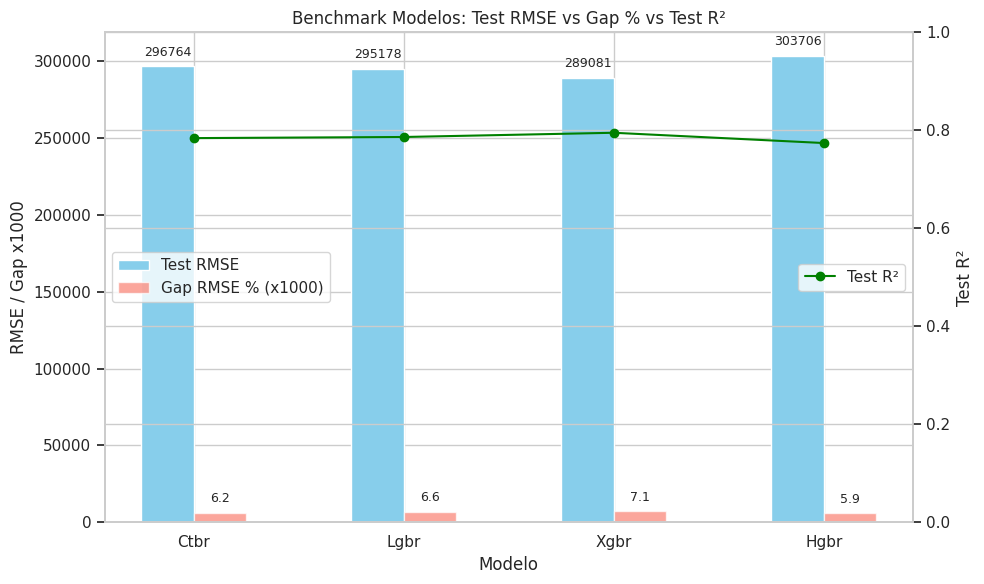

In [19]:
sns.set(style="whitegrid")

x = np.arange(len(results_df))
width = 0.25

fig, ax1 = plt.subplots(figsize=(10, 6))

bar1 = ax1.bar(
    x - width / 2, results_df["Test RMSE"], width, label="Test RMSE", color="skyblue"
)

bar2 = ax1.bar(
    x + width / 2,
    results_df["Gap RMSE %"] * 1000,
    width,
    label="Gap RMSE % (x1000)",
    color="salmon",
    alpha=0.7,
)

ax1.set_xlabel("Modelo")
ax1.set_xticks(x)
ax1.set_xticklabels(results_df["Model"])
ax1.set_ylabel("RMSE / Gap x1000")
ax1.set_title("Benchmark Modelos: Test RMSE vs Gap % vs Test R²")
ax1.legend(loc="center left")

ax2 = ax1.twinx()
ax2.plot(x, results_df["Test R2"], color="green", marker="o", label="Test R²")
ax2.set_ylabel("Test R²")
ax2.set_ylim(0, 1)
ax2.legend(loc="center right")

for rect in bar1:
    height = rect.get_height()
    ax1.text(
        rect.get_x() + rect.get_width() / 2.0,
        height + 5000,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

for rect in bar2:
    height = rect.get_height()
    ax1.text(
        rect.get_x() + rect.get_width() / 2.0,
        height + 5000,
        f"{height/1000:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

#### Instantiate the selected model

In [20]:
hgbr = HistGradientBoostingRegressor(**studies['Hgbr'].best_trial.params, random_state=42)

#### Plot Learning curve

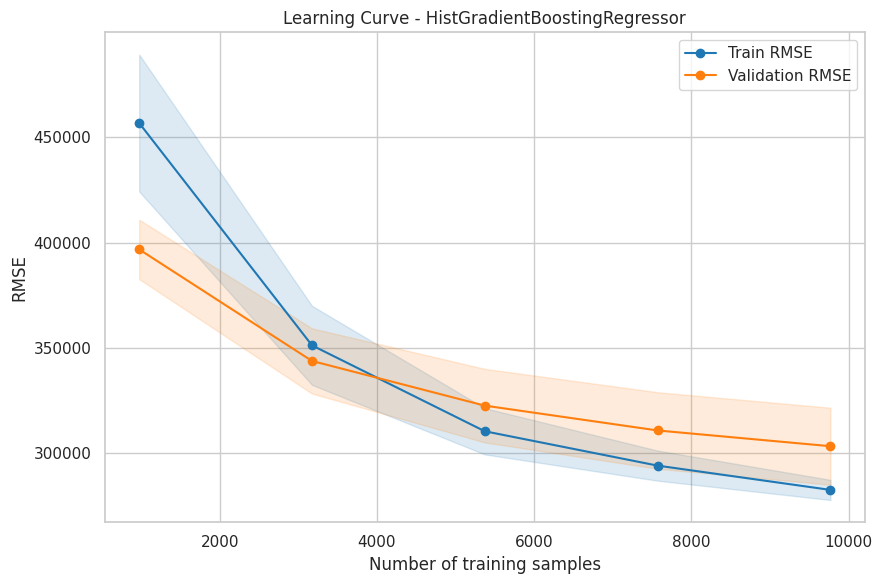

In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=hgbr,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

train_rmse = -train_scores
val_rmse = -val_scores

train_mean = train_rmse.mean(axis=1)
train_std = train_rmse.std(axis=1)

val_mean = val_rmse.mean(axis=1)
val_std = val_rmse.std(axis=1)

plt.figure(figsize=(9, 6))

plt.plot(train_sizes, train_mean, "o-", color="tab:blue", label="Train RMSE")
plt.plot(train_sizes, val_mean, "o-", color="tab:orange", label="Validation RMSE")

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="tab:blue",
)

plt.fill_between(
    train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="tab:orange"
)

plt.xlabel("Number of training samples")
plt.ylabel("RMSE")
plt.title("Learning Curve - HistGradientBoostingRegressor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Train the selected model and obtain predictions

In [22]:
hgbr.fit(X_train, y_train)
y_pred = hgbr.predict(X_test)

#### Get all housing prices by suburb and number of rooms

In [23]:
prices_df = melbourne_data_copy.groupby(["Suburb", "Rooms"], as_index=False).agg(
    Minimum_price=("Price", "min"),
    Maximum_price=("Price", "max"),
    Average_price=("Price", "mean"),
)

#### Display real prices, predictions, and comparisons of similar homes by suburb and number of rooms.

In [24]:
prediction_df = pd.DataFrame()
prediction_df["Sale price"] = y_test.astype(int)
prediction_df["Predicted price"] = y_pred.astype(int)
prediction_df["Suburb"] = suburb_copy
prediction_df["Rooms"] = X.Rooms
merge_df = pd.merge(prediction_df, prices_df, on=["Suburb", "Rooms"], how="inner")
merge_df["Average_price"] = merge_df["Average_price"].astype(int)
merge_df["Minimum_price"] = merge_df["Minimum_price"].astype(int)
merge_df["Maximum_price"] = merge_df["Maximum_price"].astype(int)
merge_df = merge_df.map(lambda x: f"{x:,}" if isinstance(x, (int, float)) else x)
merge_df.sample(10)

,Sale price,Predicted price,Suburb,Rooms,Minimum_price,Maximum_price,Average_price
522,"2,475,000","1,775,652",Parkdale,4,"1,137,500","2,475,000","1,572,187"
71,"3,300,000","1,985,773",Camberwell,3,"591,000","3,400,000","1,748,430"
74,"660,000","792,751",Lalor,4,"660,000","795,000","732,666"
270,"1,715,000","1,326,164",South Yarra,3,"740,000","3,475,000","1,654,995"
1321,"1,537,000","1,508,654",Brighton East,3,"725,000","2,291,000","1,445,495"
997,"534,000","576,449",Heidelberg,2,"420,000","738,000","571,833"
1336,"599,000","650,827",Armadale,2,"410,000","3,625,000","952,243"
529,"380,000","431,175",Reservoir,2,"240,000","1,700,000","541,425"
322,"875,000","1,458,098",Ferntree Gully,4,"748,888","890,000","836,777"
39,"1,142,500","1,026,780",Preston,4,"600,000","1,615,000","989,405"
